Extra payment per period (0 for none): 0
Lump sum amount (0 for none): 200
Lump sum timing (annual / monthly / once / none): monthly

RESULTS

Normal payoff time: 	24.42 years
With prepayments:   	19.88 years
Years saved: 			4.54

Normal interest paid: 	$156,641.94
With prepayments: 		$124,543.44
Interest saved: 		$32,098.50


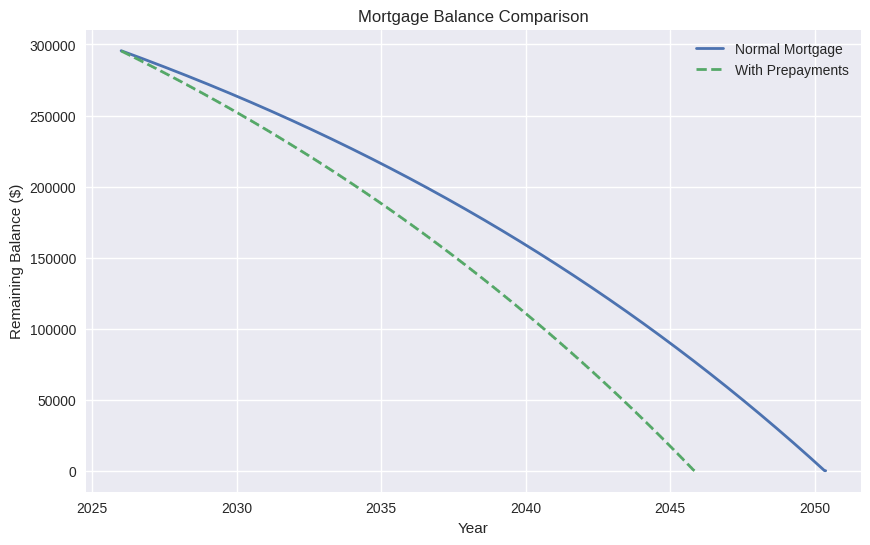

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ORIGINAL MORTGAGE PARAMETERS

current_balance = 295900.24
interest_rate = 3.80
payment_amount = 713.72
payments_per_year = 26
years_remaining = 24 + 4/12
start_year = 2026
payments_left = math.ceil(payments_per_year * years_remaining)

# PREPAYMENT OPTIONS

extra_payment = float(input("Extra payment per period (0 for none): "))
lump_sum = float(input("Lump sum amount (0 for none): "))
lump_frequency = input("Lump sum timing (annual / monthly / once / none): ").lower()

# HELPER FUNCTION

def rate_to_period(rate):
    i = rate / 100
    return (1 + i / 2) ** (2 / payments_per_year) - 1

# SIMULATION FUNCTION

def simulate(balance, use_prepayments, single_lump_payment_number = 0):

    r_per = rate_to_period(interest_rate)

    balances = []
    interests = []
    years = []

    total_interest = 0
    payment_num = 0

    while balance > 0:

        # apply lump sums
        if use_prepayments and lump_sum > 0:

            if lump_frequency == "annual" and payment_num % payments_per_year == 0:
                balance -= lump_sum

            elif lump_frequency == "monthly" and payment_num % 2 == 0:
                balance -= lump_sum

            elif lump_frequency == "once" and payment_num == single_lump_payment_number:
                balance -= lump_sum

        if balance < 0:
            balance = 0

        interest = balance * r_per
        principal_payment = payment_amount - interest

        if use_prepayments:
            principal_payment += extra_payment

        if principal_payment > balance:
            principal_payment = balance

        balance -= principal_payment

        total_interest += interest

        balances.append(balance)
        interests.append(interest)
        years.append(start_year + payment_num / payments_per_year)

        payment_num += 1

    return pd.DataFrame({
        "year": years,
        "balance": balances,
        "interest": interests
    }), total_interest, payment_num

# RUN BOTH SCENARIOS

df_normal, interest_normal, payments_normal = simulate(
    current_balance, False
)

df_prepay, interest_prepay, payments_prepay = simulate(
    current_balance, True
)

# RESULTS

interest_saved = interest_normal - interest_prepay
payments_saved = payments_normal - payments_prepay
years_saved = payments_saved / payments_per_year

print("\nRESULTS\n")
print(f"Normal payoff time: \t{payments_normal/payments_per_year:.2f} years")
print(f"With prepayments:   \t{payments_prepay/payments_per_year:.2f} years")
print(f"Years saved: \t\t\t{years_saved:.2f}")

print(f"\nNormal interest paid: \t${interest_normal:,.2f}")
print(f"With prepayments: \t\t${interest_prepay:,.2f}")
print(f"Interest saved: \t\t${interest_saved:,.2f}")


# PLOT

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(df_normal["year"], df_normal["balance"], label="Normal Mortgage", linewidth=2)
ax.plot(df_prepay["year"], df_prepay["balance"], linestyle="--", linewidth=2, label="With Prepayments")

ax.set_title("Mortgage Balance Comparison")
ax.set_xlabel("Year")
ax.set_ylabel("Remaining Balance ($)")
ax.grid(True)
ax.legend()

plt.show()

In [26]:
interest_saved = []

for payment in range(payments_left):
  df_prepay, interest_prepay, payments_prepay = simulate(
      current_balance, True, payment
  )
  saved = interest_normal - interest_prepay
  if(saved < 100): print(f"Payments {payment} and higher no longer save more than $100 in interest")
  interest_saved.append(saved)

print(interest_saved)

Payments 156 and higher no longer save more than $100 in interest
Payments 157 and higher no longer save more than $100 in interest
Payments 158 and higher no longer save more than $100 in interest
Payments 159 and higher no longer save more than $100 in interest
Payments 160 and higher no longer save more than $100 in interest
Payments 161 and higher no longer save more than $100 in interest
Payments 162 and higher no longer save more than $100 in interest
Payments 163 and higher no longer save more than $100 in interest
Payments 164 and higher no longer save more than $100 in interest
Payments 165 and higher no longer save more than $100 in interest
Payments 166 and higher no longer save more than $100 in interest
Payments 167 and higher no longer save more than $100 in interest
Payments 168 and higher no longer save more than $100 in interest
Payments 169 and higher no longer save more than $100 in interest
Payments 170 and higher no longer save more than $100 in interest
Payments 1